In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, auc
import math

In [2]:
# ====================== 1. LOAD DATASET GỐC ======================
print("Đang load dataset gốc...")
base_df = pd.read_csv("data/Churn_Modelling.csv")   # ← thay tên file nếu khác
print(f"Dataset gốc: {base_df.shape[0]} dòng, {base_df.shape[1]} cột")

# ====================== 2. XÓA CÁC CỘT KHÔNG CẦN THIẾT ======================
# Xóa RowNumber, CustomerId, Surname (không dùng cho model + bảo mật)
base_df = base_df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(f"Sau khi xóa cột thừa: {base_df.shape[1]} cột còn lại")

Đang load dataset gốc...
Dataset gốc: 10000 dòng, 14 cột
Sau khi xóa cột thừa: 11 cột còn lại


In [3]:
# ====================== 3. TẠO DỮ LIỆU TỔNG HỢP 50.000 DÒNG ======================
np.random.seed(42)  # để kết quả lặp lại được

print("Đang tạo 50.000 dòng synthetic dựa trên phân phối gốc...")

# Bootstrap + noise (giữ nguyên mối quan hệ giữa các biến)
df = base_df.sample(n=50000, replace=True).reset_index(drop=True)

# Thêm nhiễu Gaussian nhỏ cho các cột số (làm dữ liệu "thật" hơn)
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for col in numerical_cols:
    std = df[col].std()
    noise = np.random.normal(0, std * 0.05, size=50000)   # 5% nhiễu
    df[col] = df[col] + noise
    
    # Giới hạn hợp lý
    if col == 'Age':
        df[col] = df[col].clip(18, 92)
    elif col == 'CreditScore':
        df[col] = df[col].clip(350, 850)
    elif col == 'Tenure':
        df[col] = df[col].clip(0, 10)
    elif col == 'Balance':
        df[col] = df[col].clip(0, None)
    elif col == 'NumOfProducts':
        df[col] = df[col].round().clip(1, 4).astype(int)
print("Synthetic dataset đã được tạo với 50.000 dòng.")


Đang tạo 50.000 dòng synthetic dựa trên phân phối gốc...
Synthetic dataset đã được tạo với 50.000 dòng.


In [4]:
# ====================== 4. PHÁT TRIỂN THÊM 4 FEATURE MỚI (Mobile Banking) ======================
# Những feature này rất phù hợp với dự án ngân hàng số + dễ tạo derived features sau
from sklearn.feature_selection import VarianceThreshold


print("Đang thêm feature mới phù hợp churn ngân hàng số...")

df['login_count_last_30d'] = np.random.poisson(lam=12, size=50000) * \
                                 (df['IsActiveMember'] + 0.3)
df['login_count_last_30d'] = df['login_count_last_30d'].clip(0, 60).astype(int)

df['num_transactions_last_90d'] = np.random.poisson(lam=18, size=50000) * \
                                       (df['IsActiveMember'] + 0.5)
df['num_transactions_last_90d'] = df['num_transactions_last_90d'].clip(0, 120).astype(int)

df['avg_transaction_amount'] = np.random.lognormal(mean=8.5, sigma=1.2, size=50000) * \
                                    (1 + df['Balance']/100000)
df['avg_transaction_amount'] = df['avg_transaction_amount'].clip(100, 50000).round(2)

df['complaint_count_last_12m'] = np.random.poisson(lam=0.8, size=50000) * \
                                      (1 - df['IsActiveMember'] * 0.4)
df['complaint_count_last_12m'] = df['complaint_count_last_12m'].clip(0, 8).astype(int)

df['AVG_BALANCE_3M'] = df['Balance'] * (1 + df['IsActiveMember'] * np.random.uniform(-0.02, 0.03, len(df)))
df['MAX_TRANSACTION_6M'] = (df['EstimatedSalary'] * np.random.uniform(0.01, 0.1, len(df))) * (1 + df['NumOfProducts'] * 0.1)
df['STDDEV_TRANSACTION_12M'] = df['MAX_TRANSACTION_6M'] * (np.random.uniform(0.1, 0.3, len(df)) + (1 - df['Age']/df['Age'].max()) * 0.2)

# ====================== 4.1 TẠO TẤT CẢ FEATURES THEO FRAMEWORK ======================
df['tenure_days'] = df['Tenure'] * 30
df['tenure_months'] = df['Tenure']
df['recency_days'] = 30 - df['login_count_last_30d'].clip(upper=30)   # L1M recency proxy

# 1.1 Tenure groups
df['tenure_group'] = pd.cut(df['Tenure'], bins=[0,3,6,12,24,60,np.inf], 
                            labels=['New','Early','Growth','Mature','Loyal','Veteran'])

# 1.10 Age group + Demographics
df['age_group'] = pd.cut(df['Age'], bins=[0,30,40,50,60,100], 
                         labels=['Young','Adult','Mid','Senior','Elder'])

# 1.3 Balance / Current State
df['balance_salary_ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['credit_utilization'] = df['Balance'] / (df['CreditScore'] * 10 + 1)
df['balance_trend_L3M'] = (df['Balance'] - df['AVG_BALANCE_3M']) / (df['AVG_BALANCE_3M'] + 1)

# 1.4 + 1.5 Event Count & Total Value (L3M, L12M)
df['total_txn_amount_L3M'] = df['num_transactions_last_90d'] * df['avg_transaction_amount']   # SUM_L3M
df['avg_ticket_size_L3M'] = df['avg_transaction_amount']                                    # AVG_L3M

# 1.6 Active Products
df['product_penetration'] = df['NumOfProducts'] / 4   # max 4 sản phẩm
df['cross_sell_index'] = df['NumOfProducts']

# 1.7 Active Periods (proxy)
df['active_months_L3M'] = (df['num_transactions_last_90d'] > 0).astype(int) * 3
df['activity_ratio_L3M'] = df['active_months_L3M'] / 3

# 1.8 Recency (đã có)
df['is_dormant'] = (df['recency_days'] > 90).astype(int)

# 1.9 Diversity (proxy qua sản phẩm + kênh)
df['event_diversity'] = df['NumOfProducts'] + (df['HasCrCard'] * 0.5)

# ====================== 4.2. TẤT CẢ METRICS × TIMEFRAMES (FULL) ======================
# L1M (login), L3M (txn), L6M (max txn), L12M (complaint + std)

timeframes = ['L1M', 'L3M', 'L6M', 'L12M']
metrics = ['sum', 'avg', 'max', 'std', 'count', 'cv', 'velocity']

for tf in timeframes:
    if tf == 'L1M':
        base_count = df['login_count_last_30d']
        base_value = df['avg_transaction_amount']
    elif tf == 'L3M':
        base_count = df['num_transactions_last_90d']
        base_value = df['total_txn_amount_L3M']
    elif tf == 'L6M':
        base_count = df['num_transactions_last_90d'] * 2
        base_value = df['MAX_TRANSACTION_6M']
    else:  # L12M
        base_count = df['complaint_count_last_12m'] * 10
        base_value = df['STDDEV_TRANSACTION_12M'] * 10

    df[f'count_{tf}'] = base_count
    df[f'sum_{tf}'] = base_value
    df[f'avg_{tf}'] = base_value / (base_count + 1)
    df[f'max_{tf}'] = base_value
    df[f'std_{tf}'] = df['STDDEV_TRANSACTION_12M'] if tf == 'L12M' else df['STDDEV_TRANSACTION_12M'] * 0.6
    df[f'cv_{tf}'] = df[f'std_{tf}'] / (df[f'avg_{tf}'] + 1)
    df[f'velocity_{tf}'] = df[f'count_{tf}'] / (3 if tf=='L3M' else 1)

# ====================== 4.3. ADVANCED METRICS (RFM, Growth, Ratio, Interaction) ======================
# RFM (4.1)
df['freq_score'] = pd.qcut(df['num_transactions_last_90d'], q=5, labels=[1,2,3,4,5])
df['mon_score'] = pd.qcut(df['avg_transaction_amount'], q=5, labels=[1,2,3,4,5])
df['rec_score'] = pd.qcut(df['recency_days'], q=5, labels=[5,4,3,2,1])
df['rfm_score'] = df['rec_score'].astype(int)*100 + df['freq_score'].astype(int)*10 + df['mon_score'].astype(int)

# Growth & Change (4.3)
df['sum_growth_L3M_vs_L6M'] = (df['sum_L3M'] - df['sum_L6M']) / (df['sum_L6M'].abs() + 1)
df['count_growth_L3M_vs_L1M'] = (df['count_L3M'] - df['count_L1M']) / (df['count_L1M'].abs() + 1)

# Ratio metrics (4.2)
df['inflow_outflow_ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['positive_event_ratio'] = df['num_transactions_last_90d'] / (df['complaint_count_last_12m'] + 1)
df['product_tenure_ratio'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# Volatility & Anomaly (4.4)
df['value_volatility'] = df['STDDEV_TRANSACTION_12M']
df['z_score_balance'] = (df['Balance'] - df['Balance'].mean()) / (df['Balance'].std() + 1)

# Interaction features (4.5)
df['age_balance_interact'] = df['Age'] * df['Balance']
df['product_active_interact'] = df['NumOfProducts'] * df['IsActiveMember']
df['complaint_tenure_interact'] = df['complaint_count_last_12m'] * df['Tenure']
df['login_balance_interact'] = df['login_count_last_30d'] * df['Balance']

print(f"✅ Đã tạo **{len(df.columns) - 18} features mới** theo framework. Tổng: {len(df.columns)} cột")

# ====================== 4.4. FEATURE SELECTION (Phần VI) ======================
target = 'Exited'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target]

X = df[numeric_cols].copy()

# Bước 1: Loại ít biến động
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)
kept = X.columns[selector.get_support()].tolist()

# Bước 2: Loại tương quan cao (> 0.85)
corr_matrix = X[kept].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
X_reduced = X[kept].drop(columns=to_drop, errors='ignore')

# Bước 3: Loại gần như không ảnh hưởng đến target (< 0.01)
corr_target = X_reduced.corrwith(df[target]).abs()
low_impact = corr_target[corr_target < 0.01].index.tolist()
final_numeric = X_reduced.drop(columns=low_impact, errors='ignore')

# ====================== 5. GHÉP CATEGORICAL + ONE-HOT ======================
cat_cols = ['Geography', 'Gender', 'tenure_group', 'age_group']
final_df = pd.concat([df[[target] + cat_cols], final_numeric], axis=1)
final_df = pd.get_dummies(final_df, columns=cat_cols, drop_first=True)

print("\n🎯 FINAL FEATURES SAU CLEANING (đã lấy hết metric):")
print(final_df.columns.tolist())
print(f"\nTổng số features cuối cùng: **{final_df.shape[1] - 1}** (rất tối ưu)")

# Lưu file để train model / deploy backend
final_df.to_csv('bank_churn_full_features_cleaned.csv', index=False)
print("✅ File 'bank_churn_full_features_cleaned.csv' đã sẵn sàng!")

print("✅ Dataset đã load và tạo biến phái sinh xong!")


# ====================== 5. LƯU FILE ======================

print("\n✅ HOÀN TẤT!")
print(f"File đã tạo: bank_churn_full_features_cleaned.csv")
print(f"→ Số dòng: {len(final_df)}")
print(f"→ Số cột: {final_df.shape[1]} (đã xóa thừa + thêm mới)")
print(f"→ Biến mục tiêu: Exited (churn)")
print("\nCác cột hiện có:")
print(final_df.columns.tolist())

Đang thêm feature mới phù hợp churn ngân hàng số...
✅ Đã tạo **59 features mới** theo framework. Tổng: 77 cột

🎯 FINAL FEATURES SAU CLEANING (đã lấy hết metric):
['Exited', 'CreditScore', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary', 'avg_transaction_amount', 'complaint_count_last_12m', 'total_txn_amount_L3M', 'avg_L1M', 'cv_L1M', 'cv_L3M', 'avg_L6M', 'cv_L6M', 'avg_L12M', 'count_growth_L3M_vs_L1M', 'complaint_tenure_interact', 'login_balance_interact', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'tenure_group_Early', 'tenure_group_Growth', 'tenure_group_Mature', 'tenure_group_Loyal', 'tenure_group_Veteran', 'age_group_Adult', 'age_group_Mid', 'age_group_Senior', 'age_group_Elder']

Tổng số features cuối cùng: **30** (rất tối ưu)
✅ File 'bank_churn_full_features_cleaned.csv' đã sẵn sàng!
✅ Dataset đã load và tạo biến phái sinh xong!

✅ HOÀN TẤT!
File đã tạo: bank_churn_full_features_cleaned.csv
→ Số dòng: 50000
→ Số cột: 31 (đã xóa thừa + thêm mới)



🔍 SO SÁNH PHÂN PHỐI BIẾN Exited (Churn)
📊 Dataset GỐC (10,000 mẫu):
   Không churn (0): 79.63%
   Churn (1):       20.37%

📊 Dataset SYNTHETIC (50,000 mẫu):
   Không churn (0): 79.63%
   Churn (1):       20.37%

📉 Độ lệch tỷ lệ churn: 0.00%
✅ Phân phối churn được bảo tồn rất tốt!


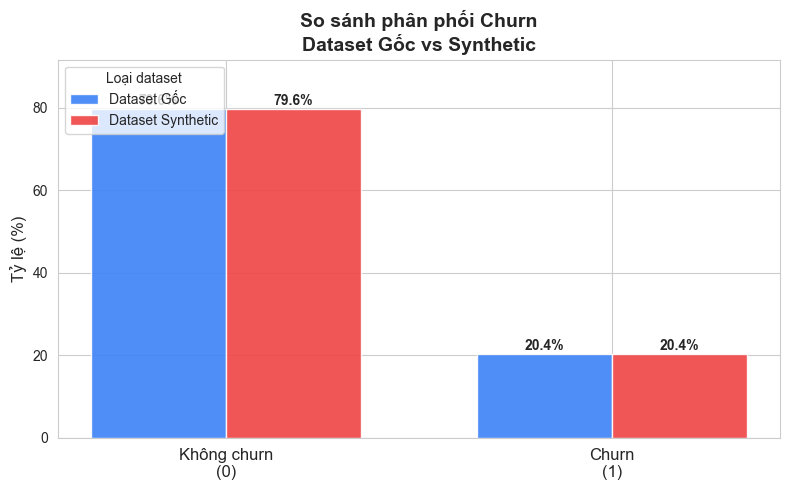

In [5]:
# ====================== 6. KIỂM TRA PHÂN PHỐI CHURN ======================
print("\n" + "="*60)
print("🔍 SO SÁNH PHÂN PHỐI BIẾN Exited (Churn)")
print("="*60)

# Kiểm tra dataset tồn tại
if 'base_df' not in globals() or 'df' not in globals():
    print("❌ Chưa có base_df hoặc df! Vui lòng load dataset trước.")
else:
    # Phân phối gốc
    orig_dist = base_df['Exited'].value_counts(normalize=True).round(4) * 100
    print(f"📊 Dataset GỐC ({len(base_df):,} mẫu):")
    print(f"   Không churn (0): {orig_dist.get(0, 0):.2f}%")
    print(f"   Churn (1):       {orig_dist.get(1, 0):.2f}%")

    # Phân phối synthetic
    synth_dist = df['Exited'].value_counts(normalize=True).round(4) * 100
    print(f"\n📊 Dataset SYNTHETIC ({len(df):,} mẫu):")
    print(f"   Không churn (0): {synth_dist.get(0, 0):.2f}%")
    print(f"   Churn (1):       {synth_dist.get(1, 0):.2f}%")

    # Kiểm tra độ lệch
    diff = abs(orig_dist.get(1, 0) - synth_dist.get(1, 0))
    print(f"\n📉 Độ lệch tỷ lệ churn: {diff:.2f}%")
    if diff < 1:
        print("✅ Phân phối churn được bảo tồn rất tốt!")
    elif diff < 3:
        print("⚠️  Phân phối khá gần, vẫn chấp nhận được.")
    else:
        print("⚠️  Phân phối lệch khá nhiều, nên điều chỉnh lại synthetic.")

    # ====================== BIỂU ĐỒ ĐẸP (Seaborn) ======================
    plt.figure(figsize=(8, 5))
    sns.set_style("whitegrid")
    
    x = [0, 1]
    width = 0.35
    
    plt.bar([i - width/2 for i in x], 
            [orig_dist.get(0, 0), orig_dist.get(1, 0)], 
            width=width, label='Dataset Gốc', color= '#3b82f6', alpha=0.9)
    
    plt.bar([i + width/2 for i in x], 
            [synth_dist.get(0, 0), synth_dist.get(1, 0)], 
            width=width, label='Dataset Synthetic', color='#ef4444', alpha=0.9)

    # Hiển thị % trên cột
    for i, v in enumerate([orig_dist.get(0, 0), orig_dist.get(1, 0)]):
        plt.text(i - width/2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    for i, v in enumerate([synth_dist.get(0, 0), synth_dist.get(1, 0)]):
        plt.text(i + width/2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

    plt.xticks([0, 1], ['Không churn\n(0)', 'Churn\n(1)'], fontsize=12)
    plt.ylabel('Tỷ lệ (%)', fontsize=12)
    plt.title('So sánh phân phối Churn\nDataset Gốc vs Synthetic', fontsize=14, fontweight='bold')
    plt.legend(title='Loại dataset', loc='upper left')
    plt.ylim(0, max(orig_dist.max(), synth_dist.max()) * 1.15)
    
    plt.tight_layout()
    plt.show()

🚀 === EDA PRO VERSION - BANK CHURN ===
=== 1. THÔNG TIN DATASET ===
Shape: 50,000 rows × 77 columns
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 77 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   CreditScore                50000 non-null  float64 
 1   Geography                  50000 non-null  str     
 2   Gender                     50000 non-null  str     
 3   Age                        50000 non-null  float64 
 4   Tenure                     50000 non-null  float64 
 5   Balance                    50000 non-null  float64 
 6   NumOfProducts              50000 non-null  int64   
 7   HasCrCard                  50000 non-null  int64   
 8   IsActiveMember             50000 non-null  int64   
 9   EstimatedSalary            50000 non-null  float64 
 10  Exited                     50000 non-null  int64   
 11  login_count_last_30d       50000 non-null  int64   
 12 

C:\Users\Admin\AppData\Local\Temp\ipykernel_7076\2098422462.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, ax=ax[1], palette=['#3b82f6','#ef4444'])


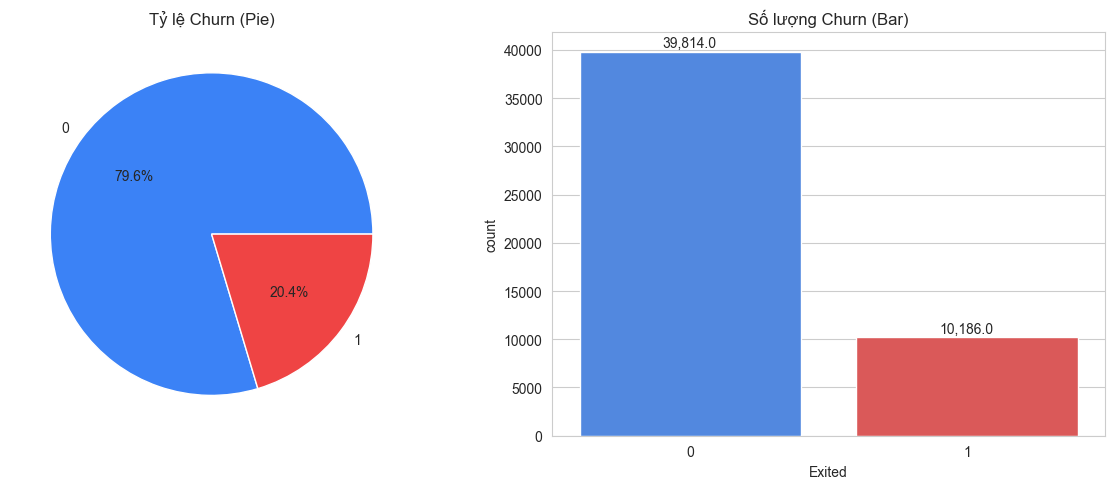


=== 4. MISSING VALUES ===
                    0     %
tenure_group     1041  2.08
Geography           0  0.00
Gender              0  0.00
Age                 0  0.00
CreditScore         0  0.00
Balance             0  0.00
NumOfProducts       0  0.00
HasCrCard           0  0.00
IsActiveMember      0  0.00
EstimatedSalary     0  0.00

=== 5. CHURN RATE THEO CÁC BIẾN PHÂN LOẠI ===

Churn rate theo Geography:
Geography
Germany    33.1
Spain      16.4
France     16.0
Name: Exited, dtype: float64

Churn rate theo Gender:
Gender
Female    25.2
Male      16.4
Name: Exited, dtype: float64

Churn rate theo HasCrCard:
HasCrCard
0    20.7
1    20.3
Name: Exited, dtype: float64

Churn rate theo IsActiveMember:
IsActiveMember
0    26.8
1    14.4
Name: Exited, dtype: float64

Churn rate theo NumOfProducts:
NumOfProducts
4    100.0
3     81.9
1     27.6
2      7.4
Name: Exited, dtype: float64

Churn rate theo tenure_group:
tenure_group
Early     20.6
New       20.5
Growth    20.0
Name: Exited, dtype:

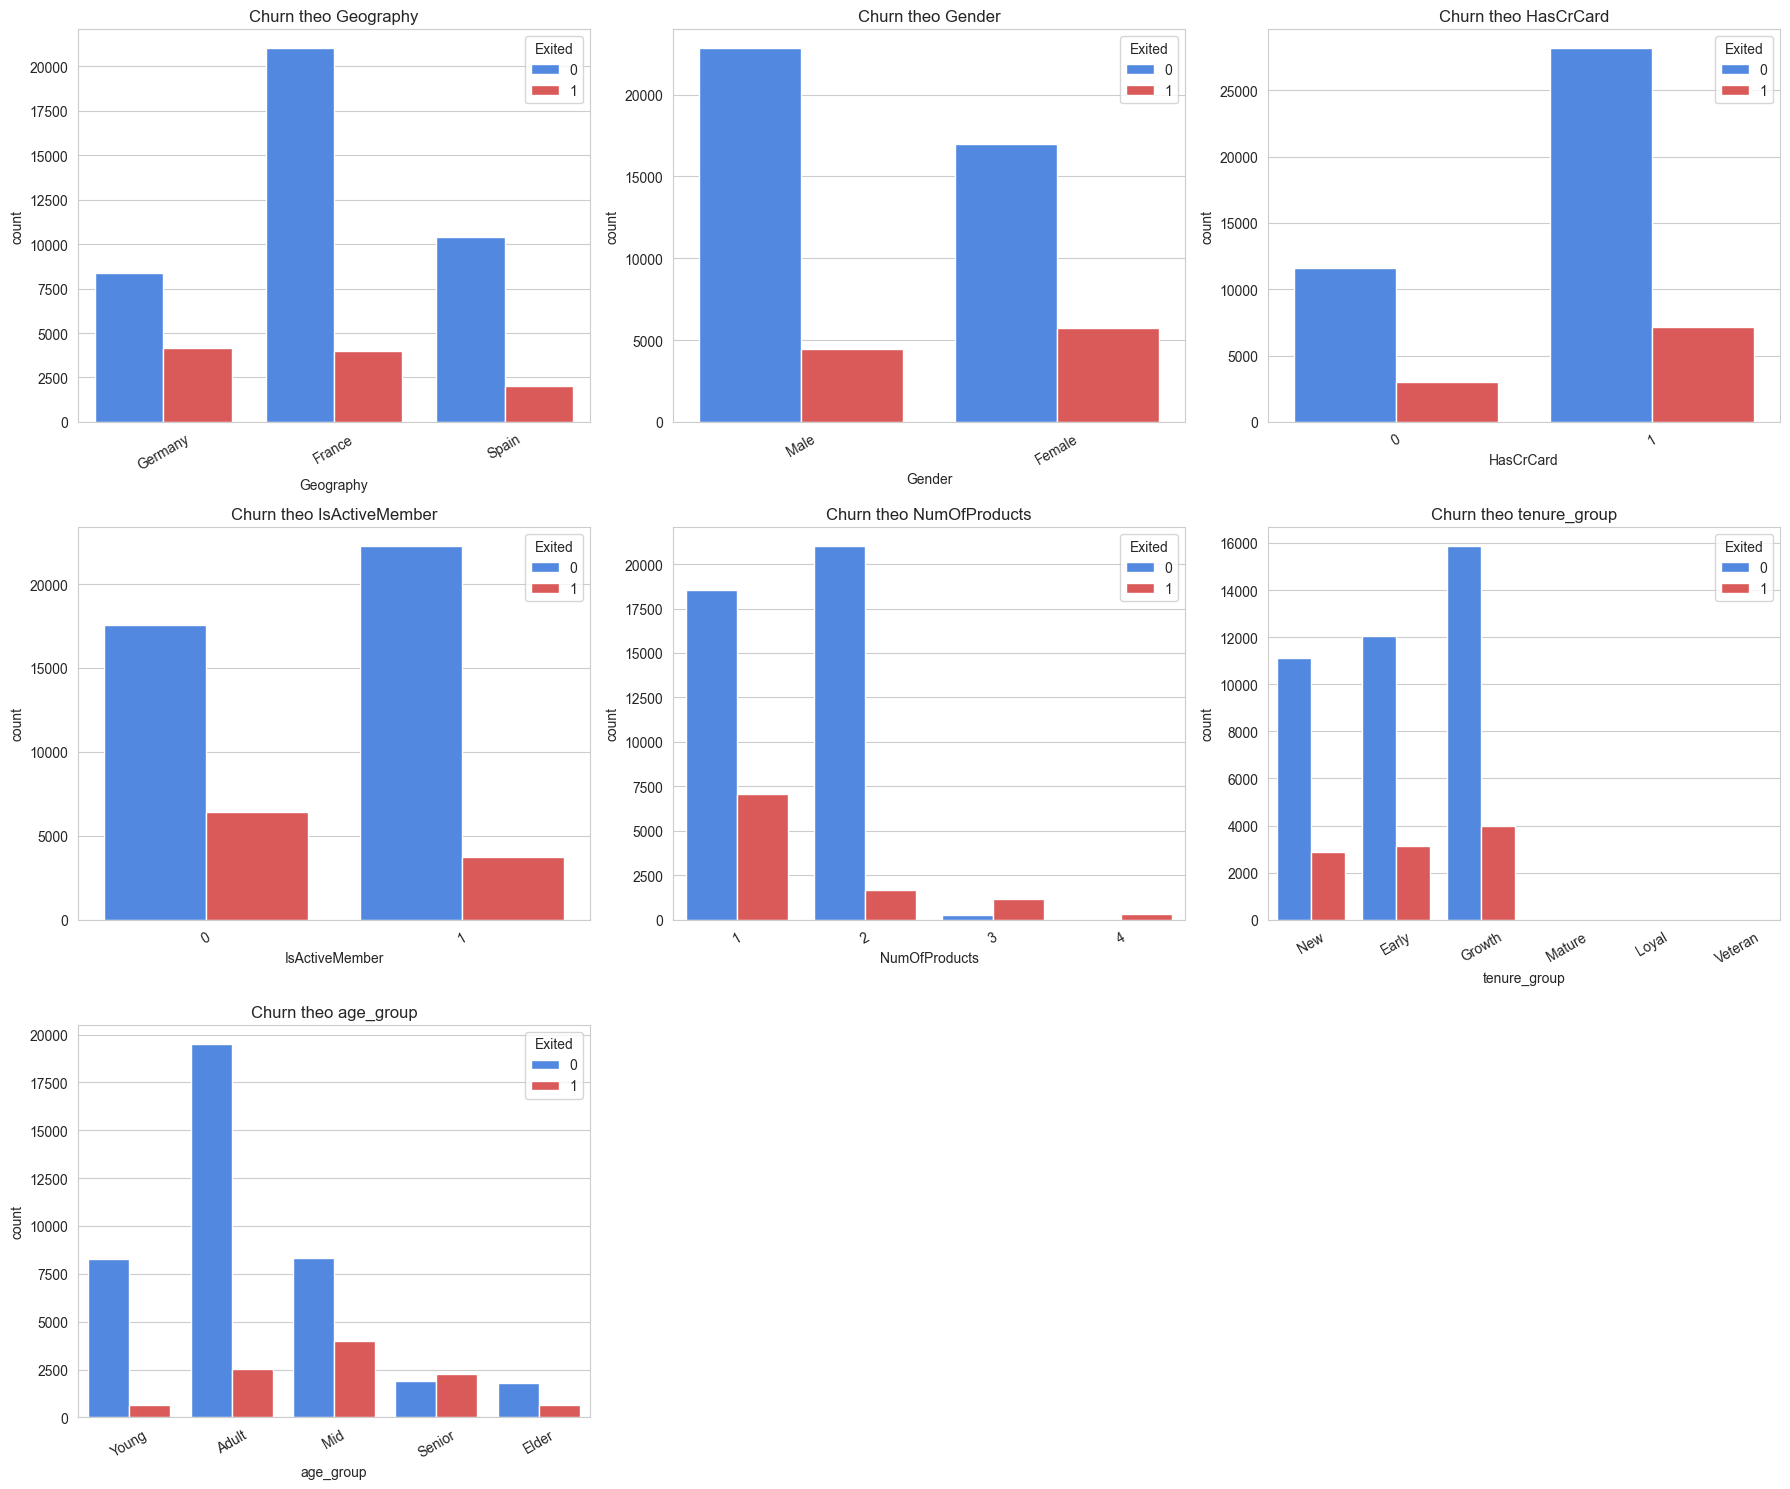


=== 6. PHÂN PHỐI NUMERICAL THEO CHURN (Boxplot) ===


C:\Users\Admin\AppData\Local\Temp\ipykernel_7076\2098422462.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=df, ax=axes[i], palette=['#3b82f6','#ef4444'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_7076\2098422462.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=df, ax=axes[i], palette=['#3b82f6','#ef4444'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_7076\2098422462.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=df, ax=axes[i], palette=['#3b82f6','#ef444

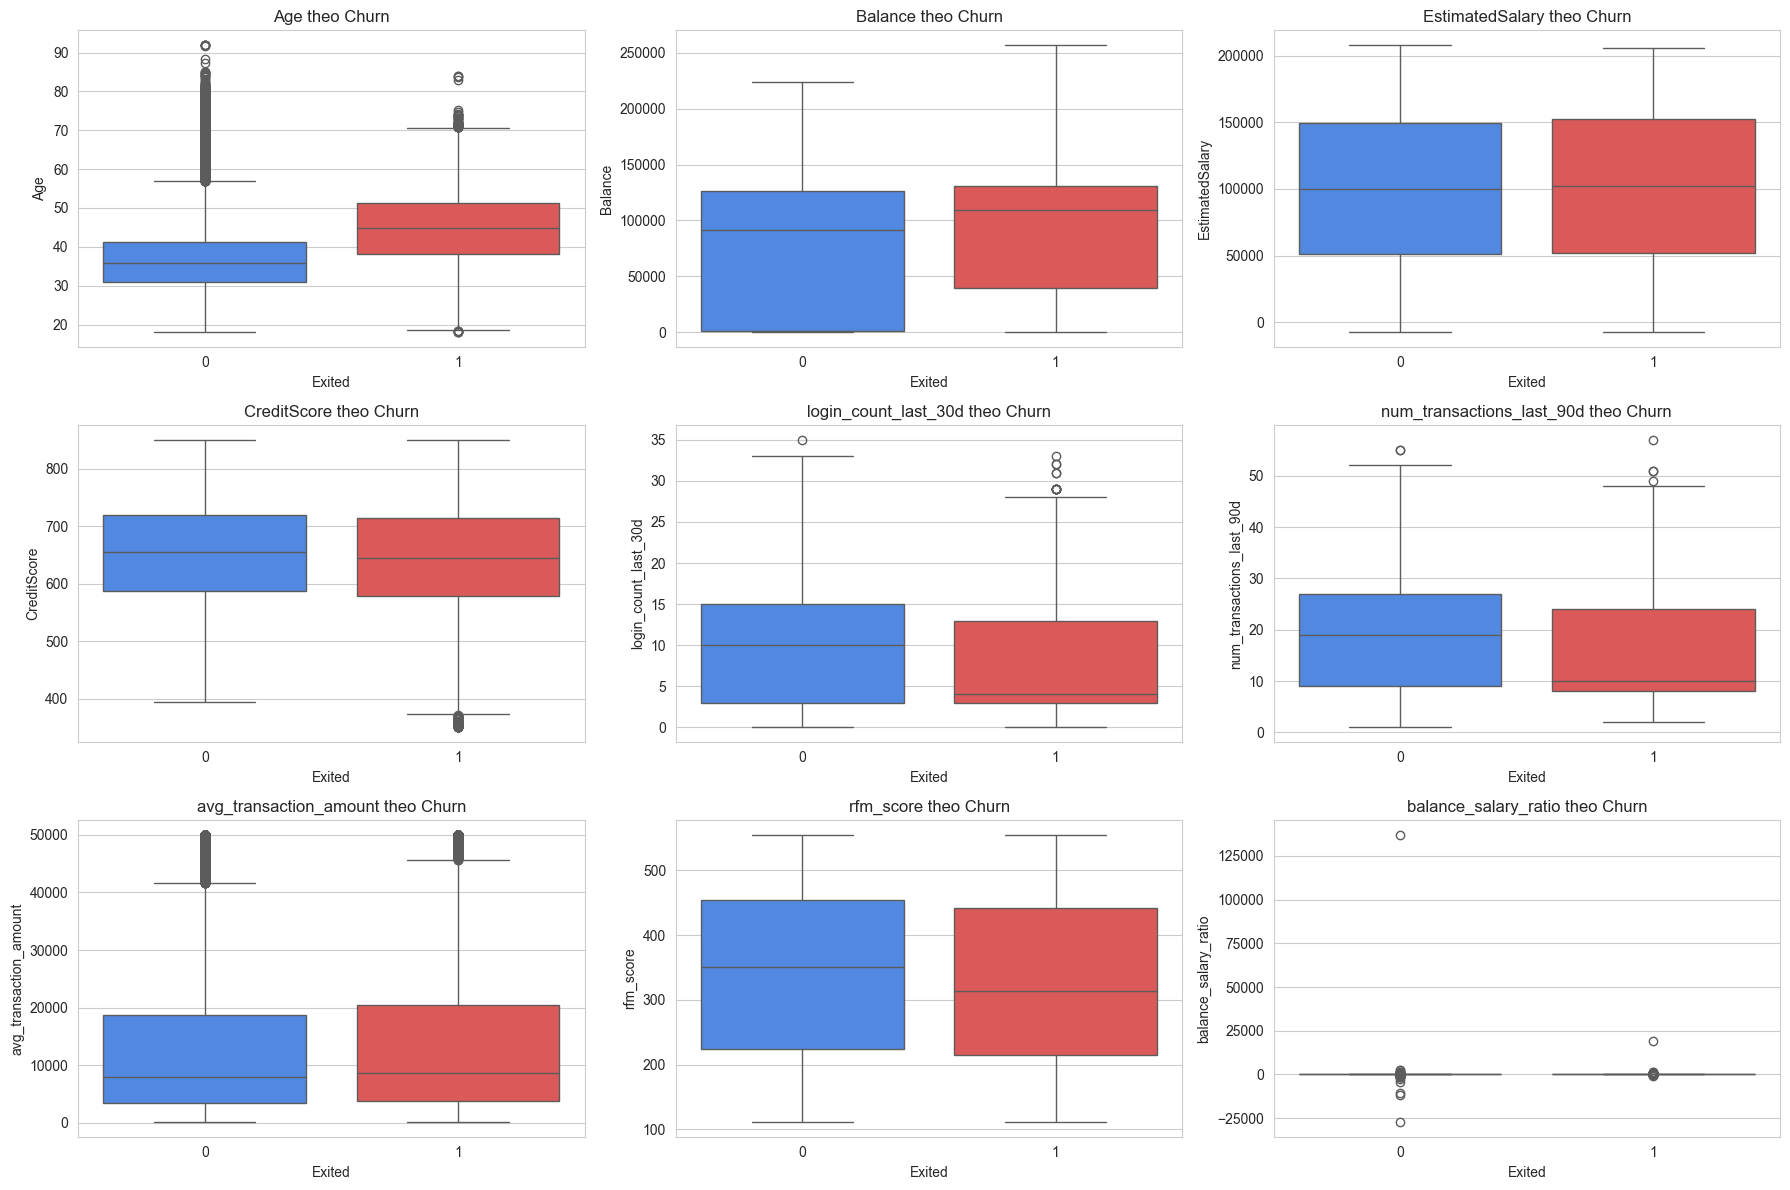


=== 7. CORRELATION HEATMAP (Top features) ===
Top 10 features tương quan nhất với Exited:
Exited                       1.000000
Age                          0.281747
age_balance_interact         0.206113
IsActiveMember               0.154284
velocity_L3M                 0.135964
count_L6M                    0.135964
velocity_L6M                 0.135964
num_transactions_last_90d    0.135964
count_L3M                    0.135964
recency_days                 0.132569
Name: Exited, dtype: float64


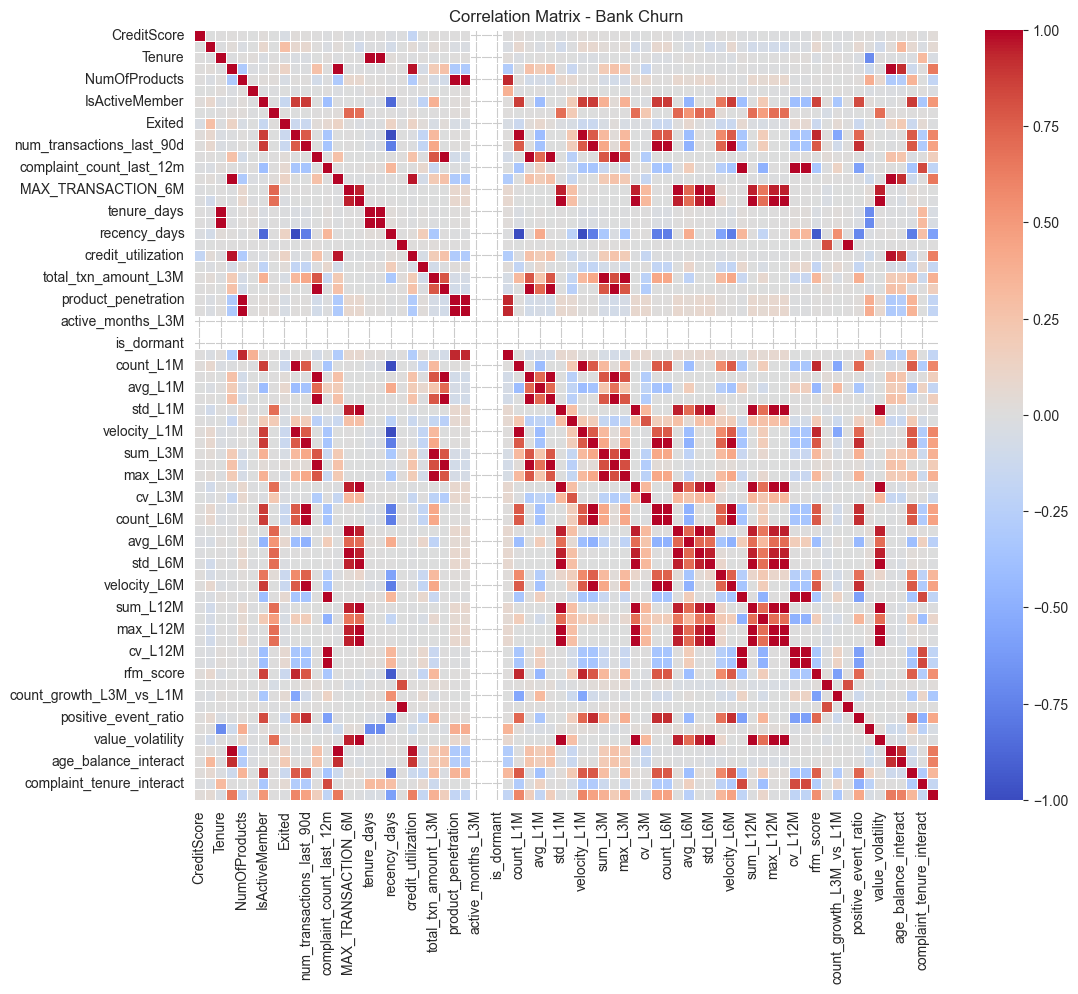


✅ EDA PRO hoàn tất! Dataset đã được phân tích sâu.


In [ ]:
# ====================== 6. EDA (Phân tích sâu) ======================
sns.set_style("whitegrid")
print("🚀 === EDA PRO VERSION - BANK CHURN ===")

# ====================== 1. THÔNG TIN CƠ BẢN ======================
print("=== 1. THÔNG TIN DATASET ===")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.info())

print("\n=== 2. THỐNG KÊ MÔ TẢ (5 số liệu chính) ===")
print(df.describe().round(2).T[['mean','std','min','50%','max']])

# ====================== 3. TARGET (CHURN) ======================
print("\n=== 3. PHÂN PHỐI TARGET (Churn) ===")
target_dist = df['Exited'].value_counts(normalize=True).round(4) * 100
print(target_dist)

# Pie chart + Bar
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df['Exited'].value_counts().plot(kind='pie', autopct='%.1f%%', ax=ax[0], colors=['#3b82f6','#ef4444'])
ax[0].set_title('Tỷ lệ Churn (Pie)')
sns.countplot(x='Exited', data=df, ax=ax[1], palette=['#3b82f6','#ef4444'])
ax[1].set_title('Số lượng Churn (Bar)')
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():,}', (p.get_x()+0.3, p.get_height()+500))
plt.tight_layout()
plt.show()

# ====================== 4. MISSING VALUES ======================
print("\n=== 4. MISSING VALUES ===")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
print(pd.concat([missing, missing_pct.rename('%')], axis=1).head(10))

if missing.sum() == 0:
    print("✅ Không có missing value nào!")

# ====================== 5. CHURN RATE THEO CATEGORICAL (bao gồm nhóm mới) ======================
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 
            'NumOfProducts', 'tenure_group', 'age_group']  # thêm nhóm mới

print("\n=== 5. CHURN RATE THEO CÁC BIẾN PHÂN LOẠI ===")
for col in cat_cols:
    if col in df.columns:
        churn_rate = df.groupby(col)['Exited'].mean().round(3) * 100
        print(f"\nChurn rate theo {col}:")
        print(churn_rate.sort_values(ascending=False))

# Trực quan (dynamic subplot)
n = len(cat_cols)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(18, 5*((n+2)//3)))
axes = axes.ravel() if n > 1 else [axes]
for i, col in enumerate(cat_cols):
    if col in df.columns:
        sns.countplot(x=col, hue='Exited', data=df, ax=axes[i], palette=['#3b82f6','#ef4444'])
        axes[i].set_title(f'Churn theo {col}')
        axes[i].tick_params(axis='x', rotation=30)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# ====================== 6. NUMERICAL FEATURES vs CHURN (Boxplot) ======================
num_cols = ['Age', 'Balance', 'EstimatedSalary', 'CreditScore', 
            'login_count_last_30d', 'num_transactions_last_90d', 
            'avg_transaction_amount', 'rfm_score', 'balance_salary_ratio']

print("\n=== 6. PHÂN PHỐI NUMERICAL THEO CHURN (Boxplot) ===")
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    if col in df.columns:
        sns.boxplot(x='Exited', y=col, data=df, ax=axes[i], palette=['#3b82f6','#ef4444'])
        axes[i].set_title(f'{col} theo Churn')
plt.tight_layout()
plt.show()

# ====================== 7. CORRELATION HEATMAP (RẤT QUAN TRỌNG) ======================
print("\n=== 7. CORRELATION HEATMAP (Top features) ===")
corr = df.corr(numeric_only=True)['Exited'].abs().sort_values(ascending=False)
print("Top 10 features tương quan nhất với Exited:")
print(corr.head(10))

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False, 
            linewidths=0.5, center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix - Bank Churn')
plt.show()

print("\n✅ EDA PRO hoàn tất! Dataset đã được phân tích sâu.")

In [7]:
# ====================== 1. SPLIT DATA ======================
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Xử lý imbalance (rất quan trọng với churn)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale_pos_weight = {scale_pos_weight:.2f}")

# ====================== 2. PHÂN LOẠI FEATURES ======================
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric features: {len(num_features)}")
print(f"Categorical features: {len(cat_features)}")

# Tính số features sau OneHot để chọn k
n_cat_unique = sum(len(X[col].unique()) for col in cat_features)
total_after_ohe = len(num_features) + n_cat_unique
k_selected = max(15, int(total_after_ohe * 0.65))   # giữ ~65% features
print(f"→ Chọn top {k_selected} features sau SelectKBest")

# ====================== 3. PREPROCESSING PIPELINE ======================
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='drop'
)

Scale_pos_weight = 3.91
Numeric features: 69
Categorical features: 7
→ Chọn top 63 features sau SelectKBest


In [8]:
print("🚀 === MODEL COMPARISON & TUNING (Multiple Models) ===")

# ====================== MODEL CONFIGS (đã sửa scale_pos_weight) ======================
model_configs = {
    "RandomForest": {
        "classifier": RandomForestClassifier(random_state=42, class_weight='balanced'),
        "param_grid": {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20],
            'classifier__min_samples_split': [2, 5]
        }
    },
    "LogisticRegression": {
        "classifier": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        "param_grid": {
            'classifier__C': [0.1, 1.0, 10],
            'classifier__penalty': ['l2']
        }
    },
    "XGBoost": {
        "classifier": XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,   # đã có từ trước
            n_jobs=-1
        ),
        "param_grid": {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__subsample': [0.8, 1.0]
        }
    }
}

results = {}

for name, config in model_configs.items():
    print(f"\n🔄 Đang tuning {name}... (GridSearchCV)")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_classif, k=k_selected)),
        ('classifier', config['classifier'])
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid=config['param_grid'],
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_pipe = grid_search.best_estimator_
    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy': round(acc, 4),
        'F1-score': round(f1, 4),
        'ROC_AUC': round(auc, 4),
        'Best_Params': grid_search.best_params_,
        'Best_Model': best_pipe
    }
    
    print(f"✅ {name} hoàn tất - Best ROC_AUC: {auc:.4f}")

🚀 === MODEL COMPARISON & TUNING (Multiple Models) ===

🔄 Đang tuning RandomForest... (GridSearchCV)
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [25 26 27] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


✅ RandomForest hoàn tất - Best ROC_AUC: 0.9139

🔄 Đang tuning LogisticRegression... (GridSearchCV)
Fitting 5 folds for each of 3 candidates, totalling 15 fits


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [25 26 27] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


✅ LogisticRegression hoàn tất - Best ROC_AUC: 0.7918

🔄 Đang tuning XGBoost... (GridSearchCV)
Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [25 26 27] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


✅ XGBoost hoàn tất - Best ROC_AUC: 0.8963



🏆 KẾT QUẢ SO SÁNH CÁC MODEL
                   Accuracy F1-score ROC_AUC
RandomForest         0.8826   0.6743  0.9139
XGBoost              0.8354   0.6588  0.8963
LogisticRegression   0.7199   0.5109  0.7918

🎉 MODEL Tối ưu: **RandomForest** với ROC_AUC = 0.9139

=== CLASSIFICATION REPORT (Best Model) ===
              precision    recall  f1-score   support

           0     0.9025    0.9558    0.9284      7963
           1     0.7754    0.5965    0.6743      2037

    accuracy                         0.8826     10000
   macro avg     0.8389    0.7761    0.8013     10000
weighted avg     0.8766    0.8826    0.8766     10000



<Figure size 600x500 with 0 Axes>

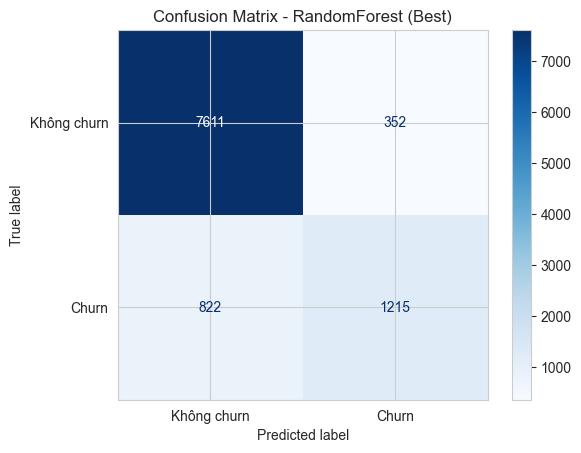

In [9]:
# ====================== BẢNG SO SÁNH KẾT QUẢ ======================
print("\n" + "="*70)
print("🏆 KẾT QUẢ SO SÁNH CÁC MODEL")
print("="*70)

results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'F1-score', 'ROC_AUC']]
print(results_df.sort_values(by='ROC_AUC', ascending=False))

# Model tối ưu
best_model_name = results_df['ROC_AUC'].idxmax()
best_auc = results_df.loc[best_model_name, 'ROC_AUC']
print(f"\n🎉 MODEL Tối ưu: **{best_model_name}** với ROC_AUC = {best_auc:.4f}")

# ====================== CHI TIẾT MODEL TH======================
best_pipe = results[best_model_name]['Best_Model']
y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT (Best Model) ===")
print(classification_report(y_test, y_pred_best, digits=4))

# Confusion Matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, 
                                        display_labels=['Không churn', 'Churn'],
                                        cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name} (Best)')
plt.show()

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [25 26 27] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



=== KẾT QUẢ RANDOM FOREST (Simple) ===
ROC-AUC     : 0.8958
Accuracy    : 0.8556
F1-score    : 0.6764

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9303    0.8850    0.9071      7963
           1     0.6223    0.7408    0.6764      2037

    accuracy                         0.8556     10000
   macro avg     0.7763    0.8129    0.7917     10000
weighted avg     0.8676    0.8556    0.8601     10000



<Figure size 600x500 with 0 Axes>

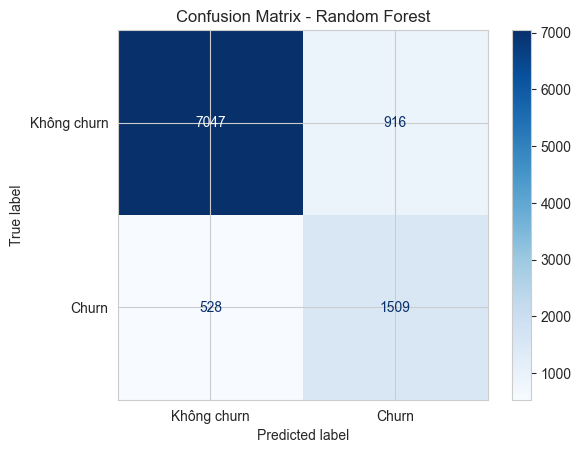

In [19]:
## Chạy model tối ưu nhất
# ====================== RANDOM FOREST ======================
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),                    # đã có từ trước
    ('feature_selection', SelectKBest(score_func=f_classif, k=k_selected)),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# ====================== TRAIN & DỰ ĐOÁN ======================
rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
y_proba = rf_pipeline.predict_proba(X_test)[:, 1]

# ====================== ĐÁNH GIÁ ĐẦY ĐỦ ======================
print("\n=== KẾT QUẢ RANDOM FOREST (Simple) ===")
print(f"ROC-AUC     : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Accuracy    : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score    : {f1_score(y_test, y_pred):.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, digits=4))
# Confusion Matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                        display_labels=['Không churn', 'Churn'],
                                        cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()


🔝 TOP 15 FEATURES QUAN TRỌNG NHẤT:
                         Feature  Importance
1                       num__Age      0.1362
16          num__event_diversity      0.0654
14      num__product_penetration      0.0612
15         num__cross_sell_index      0.0572
3             num__NumOfProducts      0.0564
39     num__age_balance_interact      0.0553
50         cat__age_group_Senior      0.0367
38          num__z_score_balance      0.0317
9            num__AVG_BALANCE_3M      0.0317
43        cat__Geography_Germany      0.0307
2                   num__Balance      0.0301
11       num__credit_utilization      0.0274
47          cat__age_group_Adult      0.0261
0               num__CreditScore      0.0253
40  num__product_active_interact      0.0208


C:\Users\Admin\AppData\Local\Temp\ipykernel_7076\192176667.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')


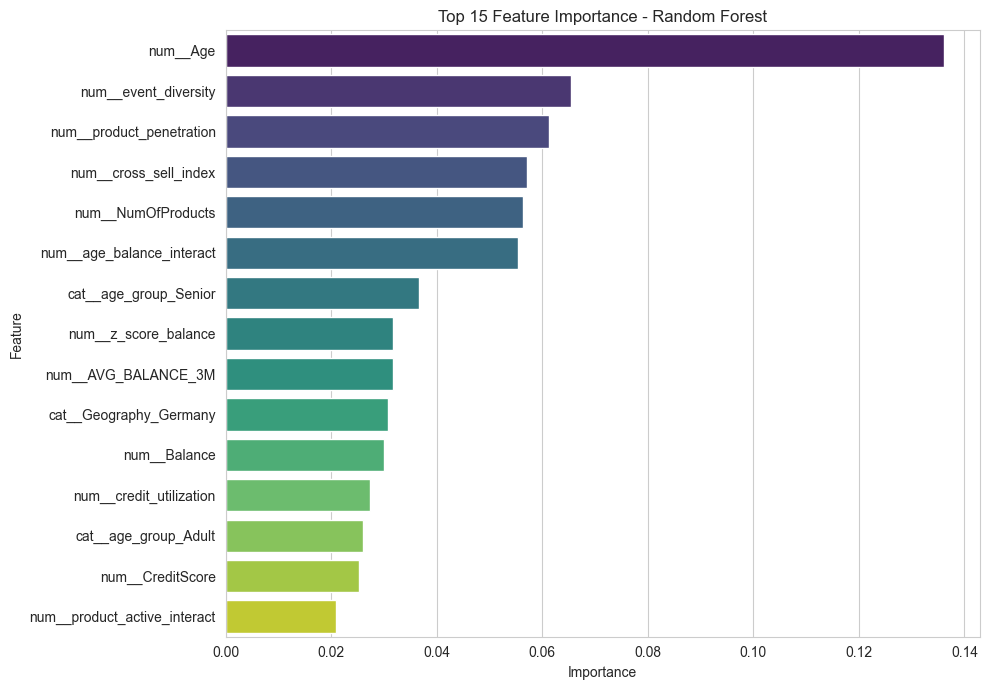

In [17]:
# ====================== FEATURE IMPORTANCE (QUAN TRỌNG NHẤT) ======================
final_features = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
selected_mask = rf_pipeline.named_steps['feature_selection'].get_support()
feature_names = final_features[selected_mask]

importances = rf_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

print("\n🔝 TOP 15 FEATURES QUAN TRỌNG NHẤT:")
print(feat_imp.round(4))

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 15 Feature Importance - Random Forest')
plt.tight_layout()
plt.show()


In [18]:
import joblib
# Lưu mô hình Random Forest tốt nhất
joblib.dump(rf_pipeline, "models/randomforest_best_model.pkl")

# Lưu preprocessor (bộ tiền xử lý) nếu bạn dùng pipeline riêng
joblib.dump(rf_pipeline.named_steps['preprocessor'], "models/preprocessor.pkl")

# Lưu ngưỡng tối ưu (ví dụ chọn threshold theo Youden’s J hoặc F1)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
joblib.dump(optimal_threshold, "models/optimal_threshold.pkl")

# Lưu feature importance nếu có
if hasattr(rf_pipeline.named_steps['classifier'], 'feature_importances_'):
    selected_features = rf_pipeline.named_steps['feature_selection'].get_support()
    preprocessed_features = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
    selected_feature_names = preprocessed_features[selected_features]
    importances = rf_pipeline.named_steps['classifier'].feature_importances_
    feat_imp = pd.DataFrame({'Feature': selected_feature_names, 'Importance': importances}) \
                .sort_values('Importance', ascending=False)
    feat_imp.to_csv("models/feature_importance.csv", index=False)

# Load lại mô hình và preprocessor
loaded_model = joblib.load("models/randomforest_best_model.pkl")
loaded_preprocessor = joblib.load("models/preprocessor.pkl")
optimal_threshold = joblib.load("models/optimal_threshold.pkl")

print(f"✅ Mô hình Random Forest, preprocessor và ngưỡng đã được lưu và tải lại thành công!")

✅ Mô hình Random Forest, preprocessor và ngưỡng đã được lưu và tải lại thành công!


In [7]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'login_count_last_30d', 'num_transactions_last_90d',
       'avg_transaction_amount', 'complaint_count_last_12m', 'AVG_BALANCE_3M',
       'MAX_TRANSACTION_6M', 'STDDEV_TRANSACTION_12M', 'tenure_days',
       'tenure_months', 'recency_days', 'tenure_group', 'age_group',
       'balance_salary_ratio', 'credit_utilization', 'balance_trend_L3M',
       'total_txn_amount_L3M', 'avg_ticket_size_L3M', 'product_penetration',
       'cross_sell_index', 'active_months_L3M', 'activity_ratio_L3M',
       'is_dormant', 'event_diversity', 'count_L1M', 'sum_L1M', 'avg_L1M',
       'max_L1M', 'std_L1M', 'cv_L1M', 'velocity_L1M', 'count_L3M', 'sum_L3M',
       'avg_L3M', 'max_L3M', 'std_L3M', 'cv_L3M', 'velocity_L3M', 'count_L6M',
       'sum_L6M', 'avg_L6M', 'max_L6M', 'std_L6M', 'cv_L6M', 'velocity_L6M',
       'count_L12M', 'sum_L12M', '